# Task 9 — Segmenting an Image Using K-Means

Using a colour photo (dog.jpg) since the task wants a complex image with lots of colours.

The idea here is to forget where pixels are and just treat each one as a point in colour
space, so three numbers: B, G and R. K-Means groups those points into K clusters, then
every pixel gets repainted with its cluster's average colour.

So the image ends up using exactly K colours, and similar regions collapse into flat
blocks.

Steps I followed from the manual: reshape the pixels, convert to float32 (kmeans needs
it), cluster, get the centres back, then rebuild the image.

Running it for K = 2, 4 and 6.

K = 2 | cluster colours (BGR):
 [[142 147 180]
 [ 59  66  90]] 

K = 4 | cluster colours (BGR):
 [[183 182 200]
 [ 53  56  75]
 [116 125 166]
 [ 70  84 116]] 

K = 6 | cluster colours (BGR):
 [[105 118 161]
 [ 52  53  70]
 [195 195 209]
 [ 76  92 125]
 [151 151 183]
 [ 59  69  97]] 



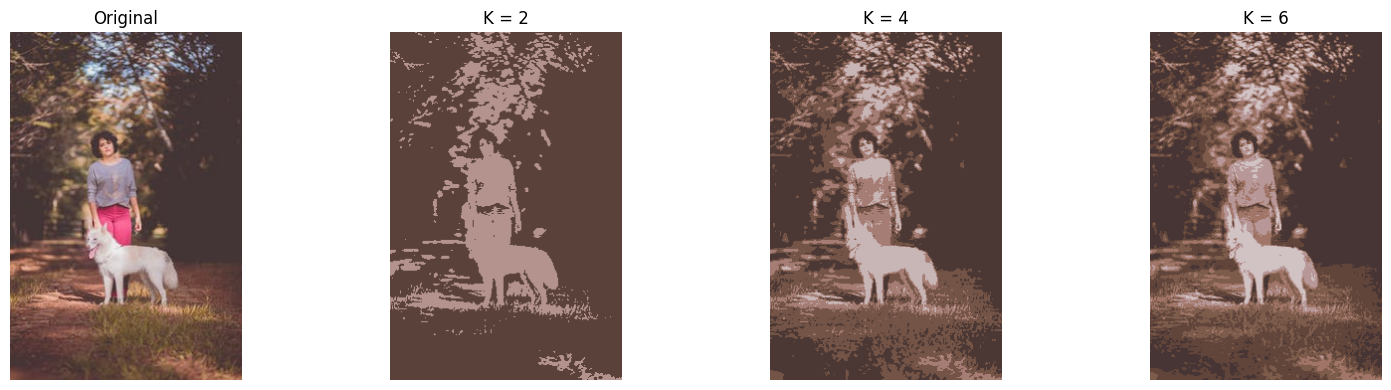

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("dog.jpeg")

if img is None:
    print("Error: dog.jpg not found")
else:
    # Flatten the image into a list of pixels, 3 values each
    pixels = img.reshape((-1, 3))
    pixels = np.float32(pixels)       # kmeans needs float32

    # Stop when it stops improving or after 10 passes
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)

    results = []
    titles = []

    for k in [2, 4, 6]:
        _, labels, centers = cv2.kmeans(
            pixels, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS
        )

        # Repaint every pixel with its cluster colour
        centers = np.uint8(centers)
        segmented = centers[labels.flatten()]
        segmented = segmented.reshape(img.shape)

        results.append(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB))
        titles.append("K = " + str(k))

        print("K =", k, "| cluster colours (BGR):\n", centers, "\n")

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    for i in range(3):
        plt.subplot(1, 4, i + 2)
        plt.imshow(results[i])
        plt.title(titles[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

### Results

| K | Clusters | Visual difference from original | Colour simplification | Major regions |
|---|---|---|---|---|
| 2 | 2 | Very big | Extreme | Subject vs background |
| 4 | 4 | Noticeable | Strong | Subject, background, shadow, highlight |
| 6 | 6 | Small | Mild | Texture and shading start coming back |

**What I noticed**

With K=2 the whole image becomes two flat colours. It basically just splits light from
dark, so a lot of real detail is gone, but the regions you do get are very clean.

K=4 is the most useful one. The main object, the background and the shadow areas show up
as separate blocks, which is actually a usable segmentation.

K=6 starts looking close to the original again. At that point it's more like a posterised
photo than a segmentation.

**Trade-off:** low K gives clean regions but throws away real differences; high K keeps
detail but stops being a segmentation.

**One limitation worth mentioning:** K-Means only looks at colour and completely ignores
where a pixel is. Two separate objects on opposite sides of the image get the same label
if they happen to be the same colour. So it simplifies the image rather than actually
finding objects.